# Comprehensive Guide to Pandas, Matplotlib, and Seaborn

This notebook provides a systematic overview of key Python libraries for data analysis and visualization: **Pandas**, **Matplotlib**, and **Seaborn**. It includes explanations, code examples, and case studies.

## 1. Pandas Library

Pandas is a powerful Python library used for:
1.  **Data Analysis**: Exploring and summarizing data.
2.  **Data Manipulation**: Transforming, filtering, and reshaping data.
3.  **Data Cleaning**: Handling missing values and inconsistencies.
4.  **Structured Data**: Working with labeled or relational data efficiently.

The two primary data structures in Pandas are:
*   **Series**: A one-dimensional labeled array (like a single column).
*   **DataFrame**: A two-dimensional labeled data structure (like a spreadsheet or SQL table).

In [4]:
import numpy as np
import pandas as pd

# Suppress warnings for cleaner output (optional)
import warnings
warnings.filterwarnings('ignore')

### 1.1 Creating Series and DataFrames

In [5]:
# --- Series Creation ---
print("--- Series Examples ---")
# From a list
s1 = pd.Series([10, 20, 30, 40, 50])
print("Series from list:\n", s1)

# With custom index
s2 = pd.Series([100, 200, 300], index=['a', 'b', 'c'])
print("\nSeries with custom index:\n", s2)

# Accessing by label
print(f"\nAccessing element with label 'a': {s2['a']}")

# --- DataFrame Creation ---
print("\n--- DataFrame Examples ---")
# From a dictionary
data_dict = {"Name": ["Amit", "Neha", "Raj"], "Marks": [85, 92, 78]}
df1 = pd.DataFrame(data_dict)
print("DataFrame from dictionary:\n", df1)

# From a list of lists
data_list = [["Amit", 85], ["Neha", 92], ["Raj", 78]]
df2 = pd.DataFrame(data_list, columns=['Name', 'Marks'])
print("\nDataFrame from list of lists:\n", df2)

# Another example
data_mixed = [["P", 23, "Mumbai"], ["K", 25, "Bhubaneswar"], ["L", 30, "Pune"]]
df3 = pd.DataFrame(data_mixed, columns=['Name', 'Age', 'City'])
print("\nAnother DataFrame:\n", df3)

--- Series Examples ---
Series from list:
 0    10
1    20
2    30
3    40
4    50
dtype: int64

Series with custom index:
 a    100
b    200
c    300
dtype: int64

Accessing element with label 'a': 100

--- DataFrame Examples ---
DataFrame from dictionary:
    Name  Marks
0  Amit     85
1  Neha     92
2   Raj     78

DataFrame from list of lists:
    Name  Marks
0  Amit     85
1  Neha     92
2   Raj     78

Another DataFrame:
   Name  Age         City
0    P   23       Mumbai
1    K   25  Bhubaneswar
2    L   30         Pune


### 1.2 Reading Data from Files

Pandas can read data from various file formats like CSV, Excel, JSON, SQL, etc. The examples assume the files exist in the environment. If not, we'll create sample data.

In [6]:
# Creating sample CSV and Excel files for demonstration
sample_data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'Age': [25, 30, 35, 40, 45],
    'Salary': [50000, 60000, 70000, 80000, 90000],
    'City': ['New York', 'London', 'Paris', 'Tokyo', 'Berlin']
}
df_sample = pd.DataFrame(sample_data)

# Save to CSV
df_sample.to_csv(r"D:\CDAC\2. Python\20March2026 - Numpy & Panda\data.csv", index=False)

# Save to Excel (requires openpyxl)
df_sample.to_excel(r"D:\CDAC\2. Python\20March2026 - Numpy & Panda\data.xlsx", index=False)

print("Sample data saved as 'data.csv' and 'data.xlsx'.")

# Now, read the files
df_csv = pd.read_csv(r"D:\CDAC\2. Python\20March2026 - Numpy & Panda\data.csv")
print("\nData read from CSV:\n", df_csv.head())

df_excel = pd.read_excel(r"D:\CDAC\2. Python\20March2026 - Numpy & Panda\data.xlsx")
print("\nData read from Excel:\n", df_excel.head())

Sample data saved as 'data.csv' and 'data.xlsx'.

Data read from CSV:
       Name  Age  Salary      City
0    Alice   25   50000  New York
1      Bob   30   60000    London
2  Charlie   35   70000     Paris
3    David   40   80000     Tokyo
4      Eva   45   90000    Berlin

Data read from Excel:
       Name  Age  Salary      City
0    Alice   25   50000  New York
1      Bob   30   60000    London
2  Charlie   35   70000     Paris
3    David   40   80000     Tokyo
4      Eva   45   90000    Berlin


### 1.3 Data Exploring Methods

These methods provide a quick overview of your DataFrame's structure and content.

In [7]:
print("--- Data Exploring ---")
print("1. head() - First 5 rows:\n", df_csv.head())
print("\n2. tail() - Last 5 rows:\n", df_csv.tail())
print("\n3. info() - Summary of DataFrame:\n")
df_csv.info()
print("\n4. describe() - Statistical summary:\n", df_csv.describe())
print("\n5. shape - Number of rows and columns:", df_csv.shape)
print("\n6. columns - List of column names:", list(df_csv.columns))

--- Data Exploring ---
1. head() - First 5 rows:
       Name  Age  Salary      City
0    Alice   25   50000  New York
1      Bob   30   60000    London
2  Charlie   35   70000     Paris
3    David   40   80000     Tokyo
4      Eva   45   90000    Berlin

2. tail() - Last 5 rows:
       Name  Age  Salary      City
0    Alice   25   50000  New York
1      Bob   30   60000    London
2  Charlie   35   70000     Paris
3    David   40   80000     Tokyo
4      Eva   45   90000    Berlin

3. info() - Summary of DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    5 non-null      object
 1   Age     5 non-null      int64 
 2   Salary  5 non-null      int64 
 3   City    5 non-null      object
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes

4. describe() - Statistical summary:
              Age        Salary
count   5.000000      5.000000
mean   

### 1.4 Data Selection and Filtering

*   **Column Selection**: Using `df['column']` or `df[['col1', 'col2']]`.
*   **Row Selection**: Using `df.loc[]` (label-based) or `df.iloc[]` (integer index-based).
*   **Filtering**: Using boolean conditions.

In [8]:
# Using the previously read df_csv for demonstration
df = df_csv.copy()

print("--- Data Selection and Filtering ---")
print("1. Selecting a single column:\n", df["Name"])
print("\n2. Selecting multiple columns:\n", df[["Name", "Salary"]])
print("\n3. Selecting a row by label (loc):\n", df.loc[2])  # Row with index label 2
print("\n4. Selecting a row by integer index (iloc):\n", df.iloc[0])  # First row
print("\n5. Filtering rows where Salary > 55000:\n", df[df['Salary'] > 55000])
print("\n6. Filtering with multiple conditions (Salary > 55000 AND Age < 90):\n",
      df[(df['Salary'] > 55000) & (df['Age'] < 90)])

--- Data Selection and Filtering ---
1. Selecting a single column:
 0      Alice
1        Bob
2    Charlie
3      David
4        Eva
Name: Name, dtype: object

2. Selecting multiple columns:
       Name  Salary
0    Alice   50000
1      Bob   60000
2  Charlie   70000
3    David   80000
4      Eva   90000

3. Selecting a row by label (loc):
 Name      Charlie
Age            35
Salary      70000
City        Paris
Name: 2, dtype: object

4. Selecting a row by integer index (iloc):
 Name         Alice
Age             25
Salary       50000
City      New York
Name: 0, dtype: object

5. Filtering rows where Salary > 55000:
       Name  Age  Salary    City
1      Bob   30   60000  London
2  Charlie   35   70000   Paris
3    David   40   80000   Tokyo
4      Eva   45   90000  Berlin

6. Filtering with multiple conditions (Salary > 55000 AND Age < 90):
       Name  Age  Salary    City
1      Bob   30   60000  London
2  Charlie   35   70000   Paris
3    David   40   80000   Tokyo
4      Eva   45 

### 1.5 Adding, Modifying, and Deleting Data

In [9]:
print("--- Adding, Modifying, Deleting Data ---")
# Adding a new column
df["Dept"] = ["HR", "EDU", "HR", "EDU", "HR"]
print("1. After adding 'Dept' column:\n", df)

# Modifying data in a column
df["Salary"] = df["Salary"] + 1000
print("\n2. After increasing Salary by 1000:\n", df)

# Deleting a column (axis=1 for columns, axis=0 for rows)
# Using inplace=True modifies the original DataFrame
df.drop("Dept", axis=1, inplace=True)
print("\n3. After dropping 'Dept' column:\n", df)

--- Adding, Modifying, Deleting Data ---
1. After adding 'Dept' column:
       Name  Age  Salary      City Dept
0    Alice   25   50000  New York   HR
1      Bob   30   60000    London  EDU
2  Charlie   35   70000     Paris   HR
3    David   40   80000     Tokyo  EDU
4      Eva   45   90000    Berlin   HR

2. After increasing Salary by 1000:
       Name  Age  Salary      City Dept
0    Alice   25   51000  New York   HR
1      Bob   30   61000    London  EDU
2  Charlie   35   71000     Paris   HR
3    David   40   81000     Tokyo  EDU
4      Eva   45   91000    Berlin   HR

3. After dropping 'Dept' column:
       Name  Age  Salary      City
0    Alice   25   51000  New York
1      Bob   30   61000    London
2  Charlie   35   71000     Paris
3    David   40   81000     Tokyo
4      Eva   45   91000    Berlin


### 1.6 Handling Missing Data

Real-world data often contains missing values. Pandas provides `isnull()`, `dropna()`, and `fillna()` to handle them.

In [10]:
# Create a DataFrame with missing values
data_missing = {
    "Month": ["Jan", "Feb", "Jan", "Feb", None],
    "Product": ["A", None, "A", None, "B"],
    "Sales": [1000, None, 3000, None, 5000]
}
df_missing = pd.DataFrame(data_missing)
print("--- DataFrame with Missing Data ---")
print(df_missing)

print("\n1. is null? (Boolean mask):\n", df_missing.isnull())
print("\n2. Sum of null values per column:\n", df_missing.isnull().sum())

# Dropping rows with any null values
df_dropped = df_missing.dropna()
print("\n3. After dropna() (drops rows with any NaN):\n", df_dropped)

# Filling null values
df_filled = df_missing.copy()
df_filled["Sales"].fillna(df_filled["Sales"].mean(), inplace=True) # Fill Sales with mean
df_filled["Month"].fillna("Unknown", inplace=True) # Fill Month with 'Unknown'
df_filled["Product"].fillna("Other", inplace=True) # Fill Product with 'Other'
print("\n4. After fillna():\n", df_filled)

--- DataFrame with Missing Data ---
  Month Product   Sales
0   Jan       A  1000.0
1   Feb    None     NaN
2   Jan       A  3000.0
3   Feb    None     NaN
4  None       B  5000.0

1. is null? (Boolean mask):
    Month  Product  Sales
0  False    False  False
1  False     True   True
2  False    False  False
3  False     True   True
4   True    False  False

2. Sum of null values per column:
 Month      1
Product    2
Sales      2
dtype: int64

3. After dropna() (drops rows with any NaN):
   Month Product   Sales
0   Jan       A  1000.0
2   Jan       A  3000.0

4. After fillna():
      Month Product   Sales
0      Jan       A  1000.0
1      Feb   Other  3000.0
2      Jan       A  3000.0
3      Feb   Other  3000.0
4  Unknown       B  5000.0


### 1.7 Sorting and Grouping Data

In [11]:
print("--- Sorting and Grouping ---")
# Create a sample DataFrame for grouping
data_group = {
    "Department": ["HR", "IT", "HR", "IT", "HR", "IT"],
    "Salary": [50000, 40000, 30000, 60000, 45000, 90000]
}
df_group = pd.DataFrame(data_group)
print("Original DataFrame for grouping:\n", df_group)

# Sorting by Salary in descending order
df_sorted = df_group.sort_values("Salary", ascending=False)
print("\n1. Sorted by Salary (descending):\n", df_sorted)

# Grouping by Department and calculating mean Salary
grouped_mean = df_group.groupby("Department")["Salary"].mean()
print("\n2. Grouped by Department (mean Salary):\n", grouped_mean)

--- Sorting and Grouping ---
Original DataFrame for grouping:
   Department  Salary
0         HR   50000
1         IT   40000
2         HR   30000
3         IT   60000
4         HR   45000
5         IT   90000

1. Sorted by Salary (descending):
   Department  Salary
5         IT   90000
3         IT   60000
0         HR   50000
4         HR   45000
1         IT   40000
2         HR   30000

2. Grouped by Department (mean Salary):
 Department
HR    41666.666667
IT    63333.333333
Name: Salary, dtype: float64


### 1.8 Merging DataFrames

Similar to SQL JOINs, `pd.merge()` combines DataFrames based on a common key.

In [12]:
print("--- Merging DataFrames ---")
df_left = pd.DataFrame({"ID": [1, 2, 3, 4, 5], "Name": ["A", "B", "C", "D", "E"]})
df_right = pd.DataFrame({"ID": [1, 2, 3, 4, 5], "Salary": [10000, 20000, 30000, 40000, 50000]})

print("Left DataFrame:\n", df_left)
print("\nRight DataFrame:\n", df_right)

df_merged = pd.merge(df_left, df_right, on="ID")
print("\nMerged DataFrame (Inner Join on 'ID'):\n", df_merged)

--- Merging DataFrames ---
Left DataFrame:
    ID Name
0   1    A
1   2    B
2   3    C
3   4    D
4   5    E

Right DataFrame:
    ID  Salary
0   1   10000
1   2   20000
2   3   30000
3   4   40000
4   5   50000

Merged DataFrame (Inner Join on 'ID'):
    ID Name  Salary
0   1    A   10000
1   2    B   20000
2   3    C   30000
3   4    D   40000
4   5    E   50000


### 1.9 Applying Functions (Lambda)

The `apply()` function allows you to apply a custom function to a column or row.

In [13]:
print("--- Applying Lambda Functions ---")
# Using a DataFrame from earlier
df = df_csv.copy()
print("Original DataFrame:\n", df)

# Apply a lambda to increase Salary by 10000
df['Salary'] = df['Salary'].apply(lambda x: x + 10000)
print("\nAfter applying lambda to 'Salary' (add 10000):\n", df)

--- Applying Lambda Functions ---
Original DataFrame:
       Name  Age  Salary      City
0    Alice   25   50000  New York
1      Bob   30   60000    London
2  Charlie   35   70000     Paris
3    David   40   80000     Tokyo
4      Eva   45   90000    Berlin

After applying lambda to 'Salary' (add 10000):
       Name  Age  Salary      City
0    Alice   25   60000  New York
1      Bob   30   70000    London
2  Charlie   35   80000     Paris
3    David   40   90000     Tokyo
4      Eva   45  100000    Berlin


### 1.10 Case Study 1: Student Performance Analysis

This case study demonstrates data manipulation, filtering, and adding calculated columns.

In [14]:
print("--- Case Study: Student Performance ---")
data_student = {
    "Id": [1, 2, 3, 4, 5],
    "Name": ["A", "B", "C", "D", "E"],
    "Marks": [32, 33, 75, 45, 45]
}
df_student = pd.DataFrame(data_student)
print("Original Student Data:\n", df_student)

# Filter students with marks > 40
passing_students = df_student[df_student["Marks"] > 40]
print("\n1. Students with Marks > 40:\n", passing_students)

# Add a Grade column based on marks
# Using a lambda function
df_student["Grade"] = df_student["Marks"].apply(lambda x: "A" if x > 75 else ("B" if x > 40 else "C"))
print("\n2. Student Data with Grade:\n", df_student)

# Homework Tasks (Solutions)
# 1. Lamda : Topper (Find student with highest marks)
topper = df_student.loc[df_student["Marks"].idxmax()]
print("\n3. Topper (using lambda for max marks):", topper["Name"], "with marks", topper["Marks"])

# 2. Filter the data for 'A' grade
grade_a_students = df_student[df_student["Grade"] == "A"]
print("\n4. Students with Grade 'A':\n", grade_a_students)

# 3. Add NCC marks (example: adding 3 marks to all students)
df_student["NCC_Marks"] = df_student["Marks"] + 3
print("\n5. Student Data with NCC Marks (added 3):\n", df_student)

--- Case Study: Student Performance ---
Original Student Data:
    Id Name  Marks
0   1    A     32
1   2    B     33
2   3    C     75
3   4    D     45
4   5    E     45

1. Students with Marks > 40:
    Id Name  Marks
2   3    C     75
3   4    D     45
4   5    E     45

2. Student Data with Grade:
    Id Name  Marks Grade
0   1    A     32     C
1   2    B     33     C
2   3    C     75     B
3   4    D     45     B
4   5    E     45     B

3. Topper (using lambda for max marks): C with marks 75

4. Students with Grade 'A':
 Empty DataFrame
Columns: [Id, Name, Marks, Grade]
Index: []

5. Student Data with NCC Marks (added 3):
    Id Name  Marks Grade  NCC_Marks
0   1    A     32     C         35
1   2    B     33     C         36
2   3    C     75     B         78
3   4    D     45     B         48
4   5    E     45     B         48


### 1.11 Case Study 2: Sales Analysis

This case study covers grouping, aggregation, and handling missing values in a sales dataset.

In [15]:
print("--- Case Study: Sales Analysis ---")
# Creating the sales data
data_sales = {
    "Month": ["Jan", "Feb", "Jan", "Feb", "Jan"],
    "Product": ["A", "B", "A", "A", "B"],
    "Sales": [1000, 2000, 3000, 4000, 5000]
}
df_sales = pd.DataFrame(data_sales)
print("Original Sales Data:\n", df_sales)

# Group by Product and calculate total sales
product_sales = df_sales.groupby("Product")["Sales"].sum()
print("\n1. Total Sales by Product:\n", product_sales)

# Group by Month and calculate total sales
month_sales = df_sales.groupby("Month")["Sales"].sum()
print("\n2. Total Sales by Month:\n", month_sales)

# --- Handling Missing Values in Sales Data ---
data_sales_missing = {
    "Month": ["Jan", "Feb", "Jan", "Feb", None],
    "Product": ["A", None, "A", None, "B"],
    "Sales": [1000, None, 3000, None, 5000]
}
df_sales_missing = pd.DataFrame(data_sales_missing)
print("\n--- Sales Data with Missing Values ---")
print(df_sales_missing)

print("\n3. Null Value Count:\n", df_sales_missing.isnull().sum())

# Filling missing Sales values with the mean
mean_sales = df_sales_missing["Sales"].mean()
df_sales_missing["Sales"].fillna(mean_sales, inplace=True)
print("\n4. After filling missing Sales with mean (3000):\n", df_sales_missing)

# Filling other missing values
df_sales_missing["Month"].fillna("Unknown", inplace=True)
df_sales_missing["Product"].fillna("Other", inplace=True)
print("\n5. After filling all missing values:\n", df_sales_missing)

--- Case Study: Sales Analysis ---
Original Sales Data:
   Month Product  Sales
0   Jan       A   1000
1   Feb       B   2000
2   Jan       A   3000
3   Feb       A   4000
4   Jan       B   5000

1. Total Sales by Product:
 Product
A    8000
B    7000
Name: Sales, dtype: int64

2. Total Sales by Month:
 Month
Feb    6000
Jan    9000
Name: Sales, dtype: int64

--- Sales Data with Missing Values ---
  Month Product   Sales
0   Jan       A  1000.0
1   Feb    None     NaN
2   Jan       A  3000.0
3   Feb    None     NaN
4  None       B  5000.0

3. Null Value Count:
 Month      1
Product    2
Sales      2
dtype: int64

4. After filling missing Sales with mean (3000):
   Month Product   Sales
0   Jan       A  1000.0
1   Feb    None  3000.0
2   Jan       A  3000.0
3   Feb    None  3000.0
4  None       B  5000.0

5. After filling all missing values:
      Month Product   Sales
0      Jan       A  1000.0
1      Feb   Other  3000.0
2      Jan       A  3000.0
3      Feb   Other  3000.0
4  Unknown 

## 2. Matplotlib Library

Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It is the foundation for many other plotting libraries, including Seaborn.

In [16]:
import matplotlib.pyplot as plt

# Set style for better looking plots
plt.style.use('seaborn-v0_8-whitegrid')

# Sample data
x = [1, 2, 3, 4, 5]
y = [10, 20, 30, 40, 50]
y2 = [100, 200, 300, 400, 500]

### 2.1 Basic Line Plot

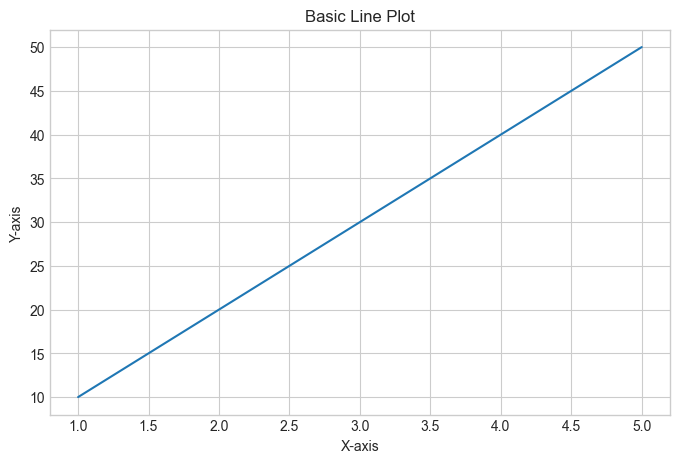

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(x, y)

plt.title("Basic Line Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

### 2.2 Styling Line Plots

You can customize line style, color, markers, and add labels and legends.

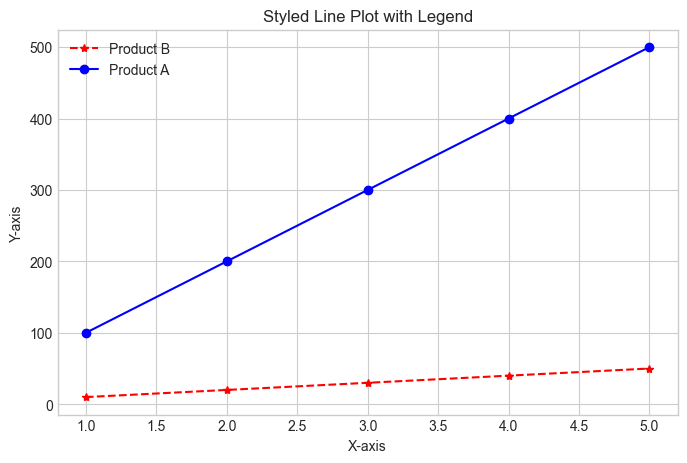

In [18]:
plt.figure(figsize=(8, 5))
# color, linestyle, marker, label for legend
plt.plot(x, y, color='red', linestyle='--', marker='*', label='Product B')
plt.plot(x, y2, color='blue', linestyle='-', marker='o', label='Product A')

plt.title("Styled Line Plot with Legend")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()  # Display the legend
plt.show()

### 2.3 Bar Charts

Use `bar()` for vertical and `barh()` for horizontal bar charts.

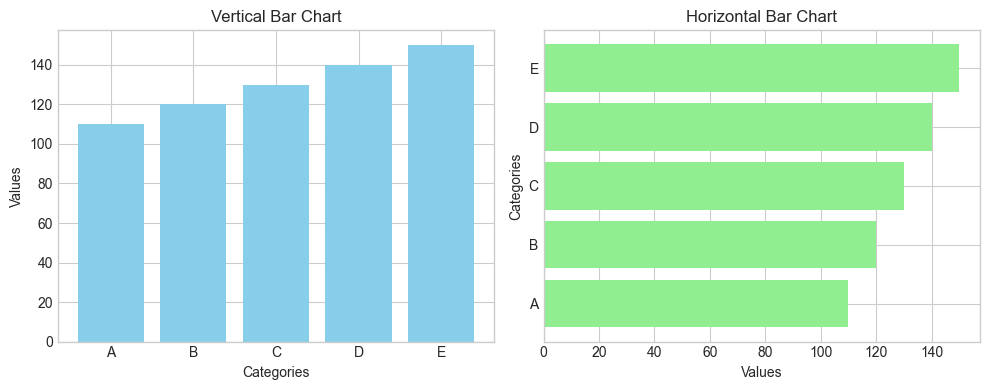

In [19]:
categories = ["A", "B", "C", "D", "E"]
values = [110, 120, 130, 140, 150]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(categories, values, color='skyblue')
plt.title("Vertical Bar Chart")
plt.xlabel("Categories")
plt.ylabel("Values")

plt.subplot(1, 2, 2)
plt.barh(categories, values, color='lightgreen')
plt.title("Horizontal Bar Chart")
plt.xlabel("Values")
plt.ylabel("Categories")

plt.tight_layout()
plt.show()

### 2.4 Histograms

Histograms show the distribution of a continuous variable. The `bins` parameter controls the number of intervals.

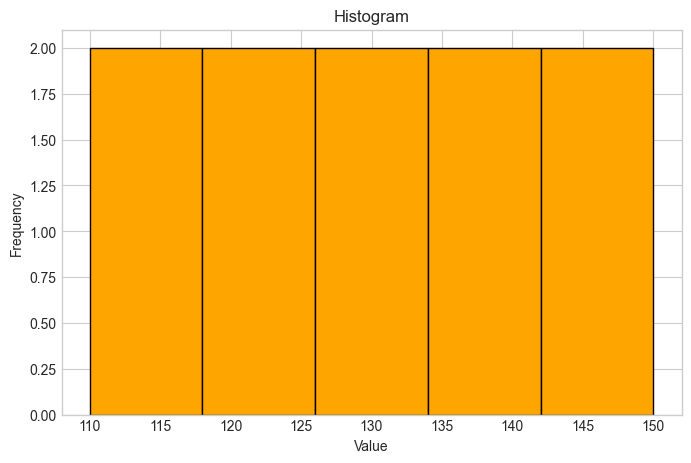

In [20]:
data_hist = [110, 120, 130, 140, 150, 110, 130, 150, 120, 140]
plt.figure(figsize=(8, 5))
plt.hist(data_hist, bins=5, color='orange', edgecolor='black')
plt.title("Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

### 2.5 Scatter Plots

Scatter plots are used to show the relationship between two continuous variables.

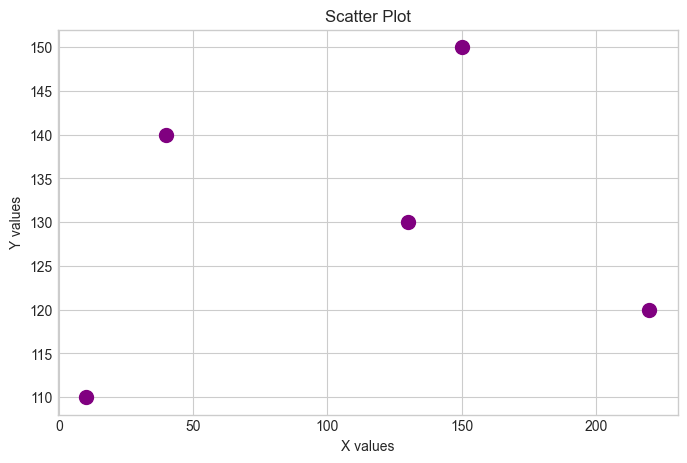

In [21]:
x_scatter = [10, 220, 130, 40, 150]
y_scatter = [110, 120, 130, 140, 150]

plt.figure(figsize=(8, 5))
plt.scatter(x_scatter, y_scatter, color='purple', s=100)  # s is marker size
plt.title("Scatter Plot")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.show()

### 2.6 Pie Charts

Pie charts represent proportions of a whole.

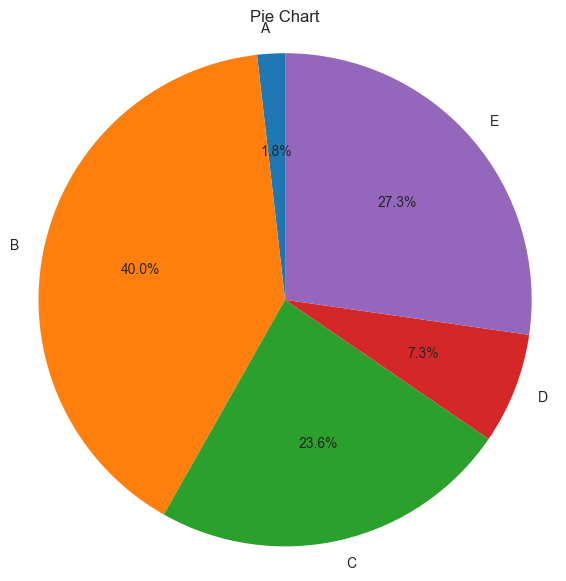

In [22]:
sizes = [10, 220, 130, 40, 150]
labels = ["A", "B", "C", "D", "E"]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Pie Chart")
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular.
plt.show()

### 2.7 Subplots

Subplots allow you to create multiple plots in a single figure.

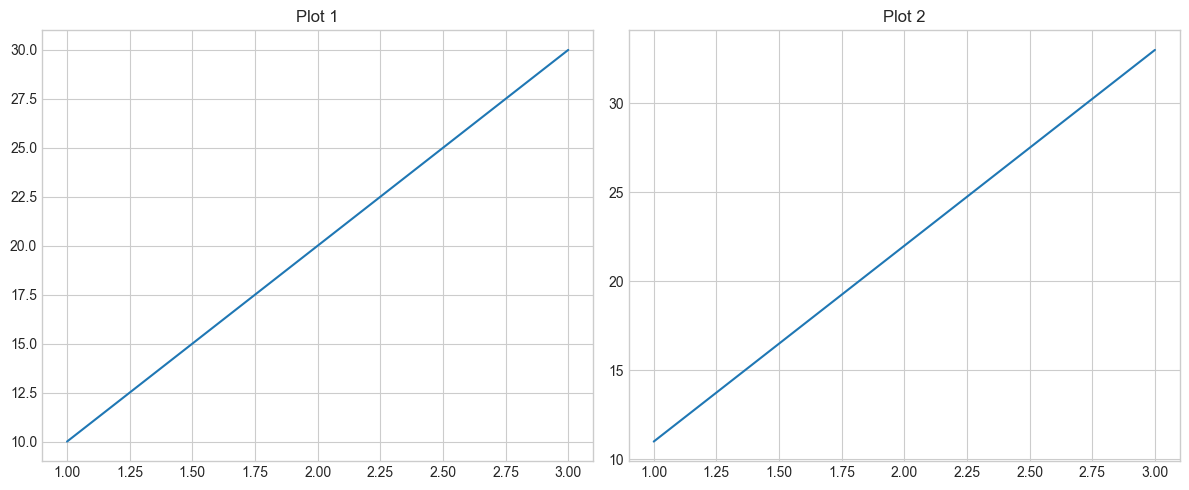

In [23]:
plt.figure(figsize=(12, 5))

# Subplot 1: 1 row, 2 columns, 1st plot
plt.subplot(1, 2, 1)
plt.plot([1, 2, 3], [10, 20, 30])
plt.title("Plot 1")

# Subplot 2: 1 row, 2 columns, 2nd plot
plt.subplot(1, 2, 2)
plt.plot([1, 2, 3], [11, 22, 33])
plt.title("Plot 2")

plt.tight_layout()
plt.show()

## 3. Seaborn Library

Seaborn is a statistical data visualization library built on top of Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

In [24]:
import seaborn as sns

# Load a sample dataset from seaborn
tips = sns.load_dataset("tips")
print("Sample dataset 'tips':\n", tips.head())

# Create a DataFrame for our own examples
data_restaurant = {
    "Day": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    "Total_Bill": [78, 20, 40, 90, 23, 95]
}
df_plot = pd.DataFrame(data_restaurant)

Sample dataset 'tips':
    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


### 3.1 Bar Plot

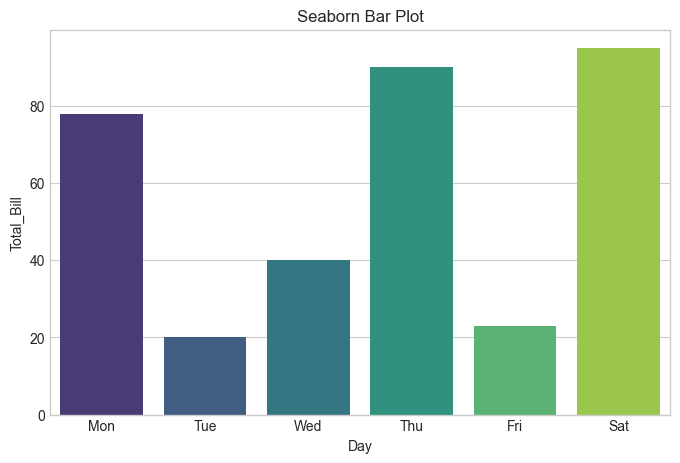

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x='Day', y='Total_Bill', palette='viridis')
plt.title('Seaborn Bar Plot')
plt.show()

### 3.2 Line Plot

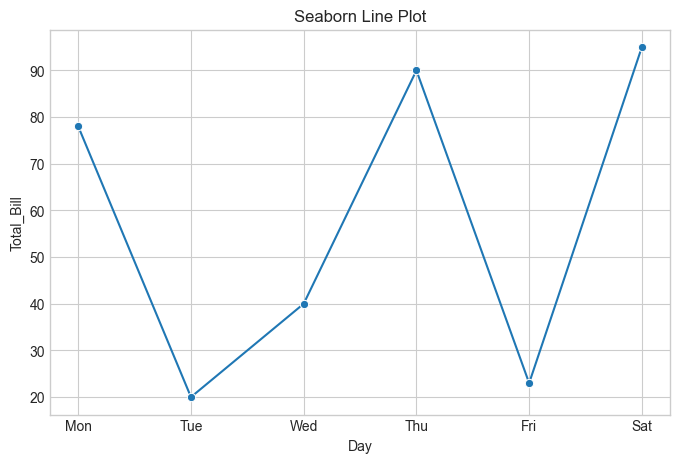

In [26]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_plot, x='Day', y='Total_Bill', marker='o')
plt.title('Seaborn Line Plot')
plt.show()

### 3.3 Box Plot

Box plots are useful for visualizing the distribution and identifying outliers.

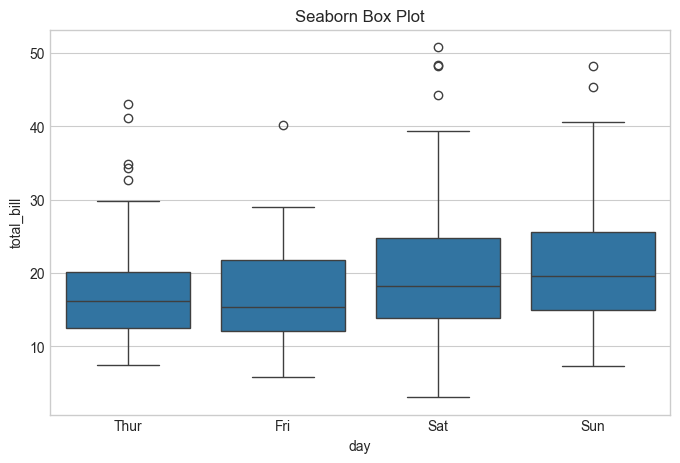

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=tips, x='day', y='total_bill')
plt.title('Seaborn Box Plot')
plt.show()

### 3.4 Violin Plot

Violin plots combine box plots with kernel density estimation, providing a richer view of the distribution.

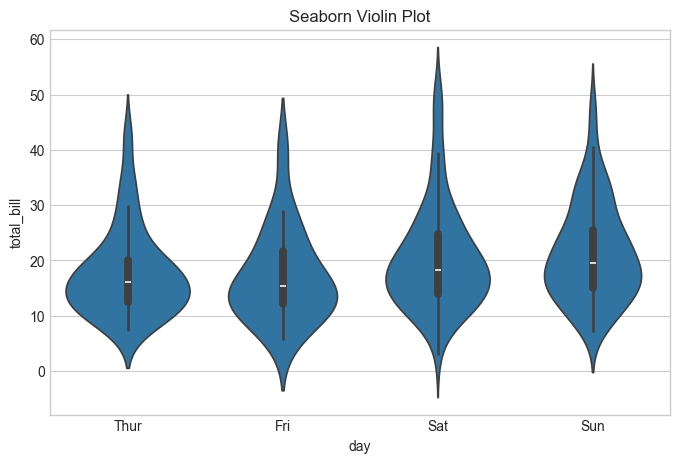

In [28]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=tips, x='day', y='total_bill')
plt.title('Seaborn Violin Plot')
plt.show()

### 3.5 Heatmap

Heatmaps are excellent for visualizing correlation matrices or any 2D data with color intensity.

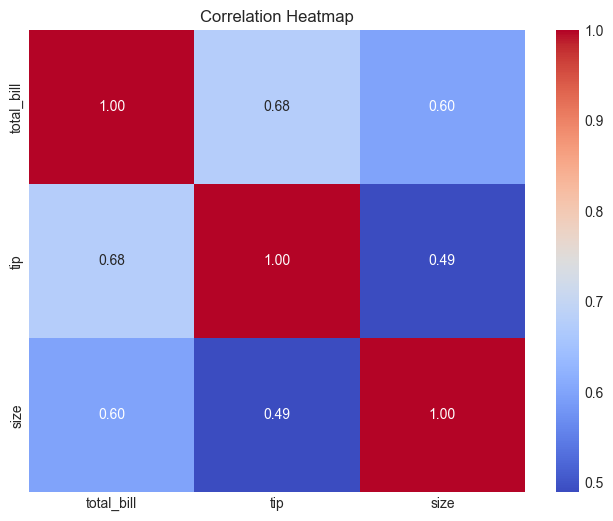

In [29]:
# Calculate correlation matrix (using numeric columns only)
corr = tips.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Summary

This notebook covered:
*   **Pandas**: Data structures (Series, DataFrame), data loading, exploration, selection, manipulation, handling missing values, grouping, merging, and applying functions.
*   **Matplotlib**: Basic and styled line plots, bar charts, histograms, scatter plots, pie charts, and subplots.
*   **Seaborn**: High-level statistical plots like bar, line, box, violin, and heatmaps.

These tools form the core of the data analysis and visualization workflow in Python.